<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Machine-Learning/blob/main/Spam_Ham_Prediction_Using_KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset:
   Unnamed: 0 label                                               text  \
0         605   ham  Subject: enron methanol ; meter # : 988291\r\n...   
1        2349   ham  Subject: hpl nom for january 9 , 2001\r\n( see...   
2        3624   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3        4685  spam  Subject: photoshop , windows , office . cheap ...   
4        2030   ham  Subject: re : indian springs\r\nthis deal is t...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  
Missing values:
Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64
Accuracy: 95.94%
Confusion Matrix:
[[736   6]
 [ 36 257]]


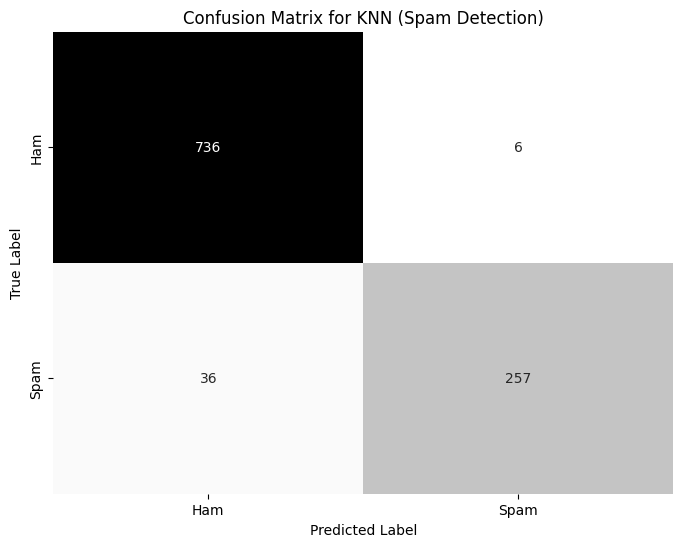

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
import seaborn as sns

# Step 1: Load dataset
df = pd.read_csv('spam_ham_dataset.csv')

print("Dataset:")
print(df.head())

# Step 2: Check missing values
print("Missing values:")
print(df.isnull().sum())
df = df.dropna()

# ---- Adjust column names if needed ----
X_text = df['text']     # change if needed
y = df['label']         # change if needed

# Convert labels (ham=0, spam=1)
y = y.map({'ham': 0, 'spam': 1})

# Step 3: Convert text to numerical features (TF-IDF)
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(X_text)

# Step 4: Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 5: Train KNN model (K=3)
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

# Step 6: Predictions
y_pred = knn_model.predict(X_test)

# Step 7: Evaluation
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy: {accuracy * 100:.2f}%")
print("Confusion Matrix:")
print(cm)

# Step 8: Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False,
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for KNN (Spam Detection)')
plt.show()